Import Libraries

In [1]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import pandas as pd

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

Read Data

In [2]:
# =========================================
# READ DATA FROM EXCEL
# =========================================

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_R00.xlsx"   # ganti sesuai nama file Anda

# Generator data
gen_df = pd.read_excel(file_path, sheet_name="Gen")

# Demand data
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Tampilkan untuk cek
#print(gen_df.head())
#print(demand_df.head())

Data Frame

In [3]:
# ============================
# CONVERT DATAFRAME → DICTIONARY
# ============================

# Set generator
G = gen_df['Unit'].tolist()

# Set time
T = demand_df['Hour'].tolist()

# Parameter generator
Pmin = dict(zip(gen_df['Unit'], gen_df['Pmin']))
Pmax = dict(zip(gen_df['Unit'], gen_df['Pmax']))
a = dict(zip(gen_df['Unit'], gen_df['a']))
b = dict(zip(gen_df['Unit'], gen_df['b']))
c = dict(zip(gen_df['Unit'], gen_df['c']))

SU_cost = dict(zip(gen_df['Unit'], gen_df['SU_Cost']))
SD_cost = dict(zip(gen_df['Unit'], gen_df['SD_Cost']))

RampUp = dict(zip(gen_df['Unit'], gen_df['Ramp_Up']))
RampDown = dict(zip(gen_df['Unit'], gen_df['Ramp_Down']))

MinUp = dict(zip(gen_df['Unit'], gen_df['Min_Up']))
MinDown = dict(zip(gen_df['Unit'], gen_df['Min_Down']))

# Demand
Demand = dict(zip(demand_df['Hour'], demand_df['Demand']))

Definisi Model + Sets

In [4]:
model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

# ============================
# RESERVE REQUIREMENT
# ============================
ReserveReq = {t: 0.10 * Demand[t] for t in Demand}


Parameter Pyomo

In [5]:
model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.Demand = Param(model.T, initialize=Demand)

model.ReserveReq = Param(model.T, initialize=ReserveReq)

Variables

In [6]:
# =====================
# Variables
# =====================
model.P = Var(model.G, model.T, domain=NonNegativeReals)
model.u = Var(model.G, model.T, domain=Binary)
model.y = Var(model.G, model.T, domain=Binary)              #startup
model.z = Var(model.G, model.T, within=Binary)              #shutdown
model.R = Var(model.G, model.T, within=NonNegativeReals)    #spinning reserve

Objective Function

In [7]:
# =========================================
# OBJECTIVE FUNCTION
# =========================================
def obj_rule(m):
    return sum(
        m.b[g] * m.P[g, t]              #Cost Koefisien b
        + m.c[g] * m.u[g, t]            #Cost Koefisien c
        + m.SU_cost[g] * m.y[g, t]      #Start Up Cost
        + m.SD_cost[g] * m.z[g, t]      #Shutdown Cost
        for g in m.G for t in m.T
    )

model.Obj = Objective(rule=obj_rule, sense=minimize)

Constraints

In [8]:
# =====================
# Constraints
# =====================

# Power balance
def balance_rule(m, t):
    return sum(m.P[g, t] for g in m.G) == m.Demand[t]

model.Balance = Constraint(model.T, rule=balance_rule)

# Capacity upper bound
def max_rule(m, g, t):
    return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

# Capacity lower bound
def min_rule(m, g, t):
    return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

model.MinCap = Constraint(model.G, model.T, rule=min_rule)

# Startup / Shutdown transition
def transition_rule(m, g, t):
    if t == 1:
        return m.u[g, t] == m.y[g, t] - m.z[g, t]
    else:
        return m.u[g, t] - m.u[g, t-1] == m.y[g, t] - m.z[g, t]

model.Transition = Constraint(model.G, model.T, rule=transition_rule)

# Ramp Up
def ramp_up_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t] - m.P[g, t-1] <= m.RampUp[g]

model.RampUpConstraint = Constraint(model.G, model.T, rule=ramp_up_rule)

# Ramp Down
def ramp_down_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t-1] - m.P[g, t] <= m.RampDown[g]

model.RampDownConstraint = Constraint(model.G, model.T, rule=ramp_down_rule)

# Minimum Up Time
def min_up_rule(m, g, t):
    MU = int(value(m.MinUp[g]))
    if t + MU - 1 > max(m.T):
        return Constraint.Skip
    return sum(m.u[g, k] for k in range(t, t + MU)) >= MU * m.y[g, t]

model.MinUpConstraint = Constraint(model.G, model.T, rule=min_up_rule)

# Minimum Down Time
def min_down_rule(m, g, t):
    MD = int(value(m.MinDown[g]))
    if t + MD - 1 > max(m.T):
        return Constraint.Skip
    return sum(1 - m.u[g, k] for k in range(t, t + MD)) >= MD * m.z[g, t]

model.MinDownConstraint = Constraint(model.G, model.T, rule=min_down_rule)

# Reserve per generator
def reserve_cap_rule(m, g, t):
    return m.P[g, t] + m.R[g, t] <= m.Pmax[g] * m.u[g, t]

model.ReserveCap = Constraint(model.G, model.T, rule=reserve_cap_rule)

# Reserve system
def system_reserve_rule(m, t):
    return sum(m.R[g, t] for g in m.G) >= m.ReserveReq[t]

model.SystemReserve = Constraint(model.T, rule=system_reserve_rule)

Solve

In [9]:
# =========================================
# Solve
# =========================================
from pyomo.opt import SolverStatus, TerminationCondition

solver = SolverFactory('cbc')
results = solver.solve(model, tee=False)

if (results.solver.status == SolverStatus.ok and
    results.solver.termination_condition == TerminationCondition.optimal):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")

Optimal solution found.


Results

In [10]:
# =====================
# Format
# =====================
def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    else:
        return round(x, 2)
    
# =====================
# Print Results
# =====================
#print("Total System Cost =", fmt(value(model.Obj)))
from pyomo.environ import value
import pandas as pd

rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    total_reserve = 0

    for g in model.G:
        p = value(model.P[g, t])
        u = value(model.u[g, t])
        y = value(model.y[g, t])
        z = value(model.z[g, t])

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)

        total_power += p
        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])

        # jika reserve aktif
        if hasattr(model, "R"):
            r = value(model.R[g, t])
            row[f"{g}_R"] = fmt(r)
            total_reserve += r

    row["Total_Power"] = fmt(total_power)
    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Total Cost"] = fmt(fuel_cost + fixed_cost + startup_cost + shutdown_cost)

    if hasattr(model, "ReserveReq") and hasattr(model, "R"):
        reserve_req = value(model.ReserveReq[t])
        row["Total_Reserve"] = fmt(total_reserve)
        row["Reserve_Req"] = fmt(reserve_req)
        row["Reserve_Margin"] = fmt(total_reserve - reserve_req)

    rows.append(row)

df_hourly = pd.DataFrame(rows)

# ==========================================================
print("\n========== TABEL A: DISPATCH ==========")
print("Keterangan: Output daya tiap unit dan keseimbangan sistem (harus = Demand)\n")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))

# ==========================================================
print("\n========== TABEL B: STATUS UNIT ==========")
print("Keterangan: Status ON/OFF unit (1 = ON, 0 = OFF)\n")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))

# ==========================================================
if "Reserve_Req" in df_hourly.columns:
    print("\n========== TABEL C: RESERVE ==========")
    print("Keterangan: Cadangan daya (spinning reserve) dan margin sistem\n")

    reserve_cols = ["Hour", "Reserve_Req"] + [f"{g}_R" for g in model.G] + ["Total_Reserve", "Reserve_Margin"]
    print(df_hourly[reserve_cols].to_string(index=False))

# ==========================================================
print("\n========== TABEL D: BIAYA ==========")
print("Keterangan: Komponen biaya pembangkitan per jam\n")

cost_cols = ["Hour", "Fuel Cost", "Fixed Cost", "Startup Cost", "Shutdown Cost", "Total Cost"]
print(df_hourly[cost_cols].to_string(index=False))

# ==========================================================
print("\n========== TABEL E: RAMPING ==========")
print("Keterangan: Perubahan daya antar jam (ΔP)\n")

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}
    if t == 1:
        for g in model.G:
            ramp_row[f"Δ{g}"] = "-"
    else:
        for g in model.G:
            dp = value(model.P[g, t]) - value(model.P[g, t-1])
            ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)
print(df_ramp.to_string(index=False))

# ==========================================================
print("\n========== TABEL F: SYSTEM SUMMARY ==========")
print("Keterangan: Ringkasan performa sistem\n")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
]

if "Reserve_Margin" in df_hourly.columns:
    summary_rows.append(["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())])

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows.append(["Total Startup Events", fmt(total_startup)])
summary_rows.append(["Total Shutdown Events", fmt(total_shutdown)])

df_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_summary.to_string(index=False))


========== TABEL A: DISPATCH ==========
Keterangan: Output daya tiap unit dan keseimbangan sistem (harus = Demand)

 Hour  Demand  G1_P  G2_P  G3_P  G4_P  G5_P  G6_P  G7_P  Total_Power
    1     260    80     0     0     0     0    90    90          260
    2     250    80     0     0     0     0    80    90          250
    3     245    80     0     0     0     0    75    90          245
    4     240    80     0     0     0     0    70    90          240
    5     245    80     0     0     0     0   120    45          245
    6     270    80     0     0     0     0   120    70          270
    7     320   110     0     0     0     0   120    90          320
    8     380   170     0     0     0     0   120    90          380
    9     430   220     0     0     0     0   120    90          430
   10     470   240     0    20     0     0   120    90          470
   11     500   270     0    20     0     0   120    90          500
   12     520   290     0    20     0     0   120    90

Grafik

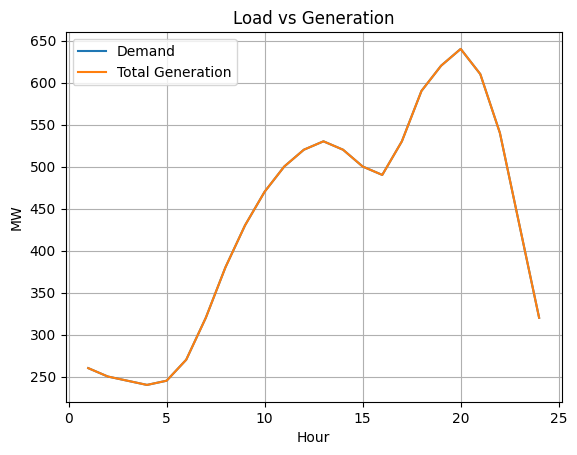

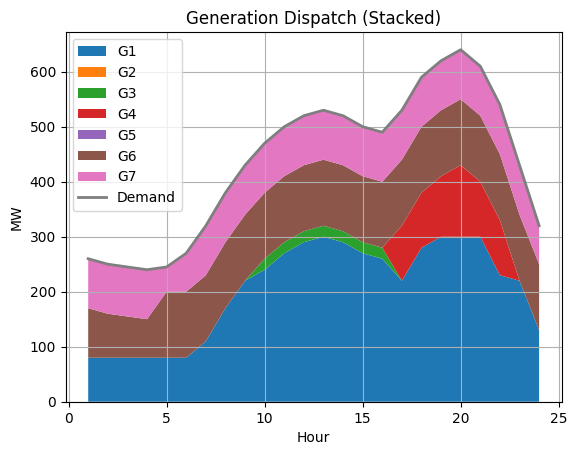

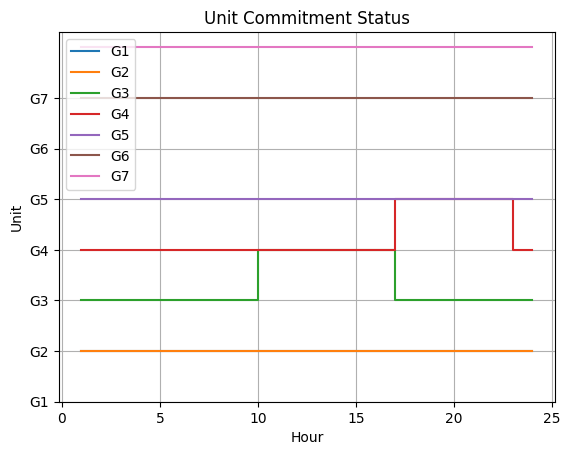

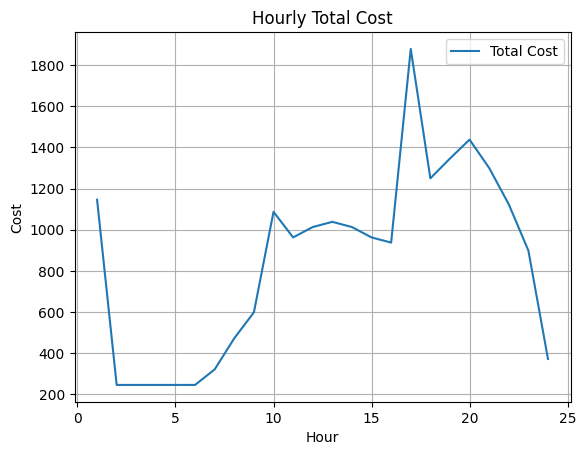

In [11]:
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD vs GENERATION
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Demand"], label="Demand")
plt.plot(df_hourly["Hour"], df_hourly["Total_Power"], label="Total Generation")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Load vs Generation")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 2. DISPATCH PER UNIT (STACKED)
# ===============================
gen_cols = [f"{g}_P" for g in model.G]

plt.figure()
plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=model.G
)

# Overlay demand
plt.plot(df_hourly["Hour"], df_hourly["Demand"], linewidth=2, label="Demand")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()


# ===============================
# 3. STATUS UNIT (ON/OFF)
# ===============================
plt.figure()

for i, g in enumerate(model.G):
    plt.step(
        df_hourly["Hour"],
        df_hourly[f"{g}_U"] + i,   # offset biar tidak numpuk
        where='post',
        label=g
    )

plt.xlabel("Hour")
plt.ylabel("Unit")
plt.title("Unit Commitment Status")
plt.yticks(range(len(model.G)), model.G)
plt.legend()
plt.grid()
plt.show()


# ===============================
# 4. TOTAL COST PER HOUR
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Total Cost"], label="Total Cost")

plt.xlabel("Hour")
plt.ylabel("Cost")
plt.title("Hourly Total Cost")
plt.legend()
plt.grid()
plt.show()